# Iris Flower Classification

A notebook for classifying Iris flower species using scikit-learn and visual exploration.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the built-in Iris dataset from sklearn
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create a pandas DataFrame for EDA and plotting
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = [target_names[i] for i in y]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Exploratory Data Analysis (EDA): shape, dtypes, null values, statistics
print(f'Shape: {iris_df.shape}')
print('\nDtypes:')
print(iris_df.dtypes)
print('\nNull values:')
print(iris_df.isnull().sum())
print('\nDescriptive statistics:')
print(iris_df.describe(include='all'))

Shape: (150, 5)

Dtypes:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Null values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count          150.000000        150.000000         150.000000   
unique                NaN               NaN                NaN   
top                   NaN               NaN                NaN   
freq                  NaN               NaN                NaN   
mean             5.843333          3.057333           3.758000   
std              0.828066          0.435866           1.765298   
min              4.300000          2.000000           1.000000   
25%              5.100000          2.800000           1.600000   
50%              5.800000          3.000000           4

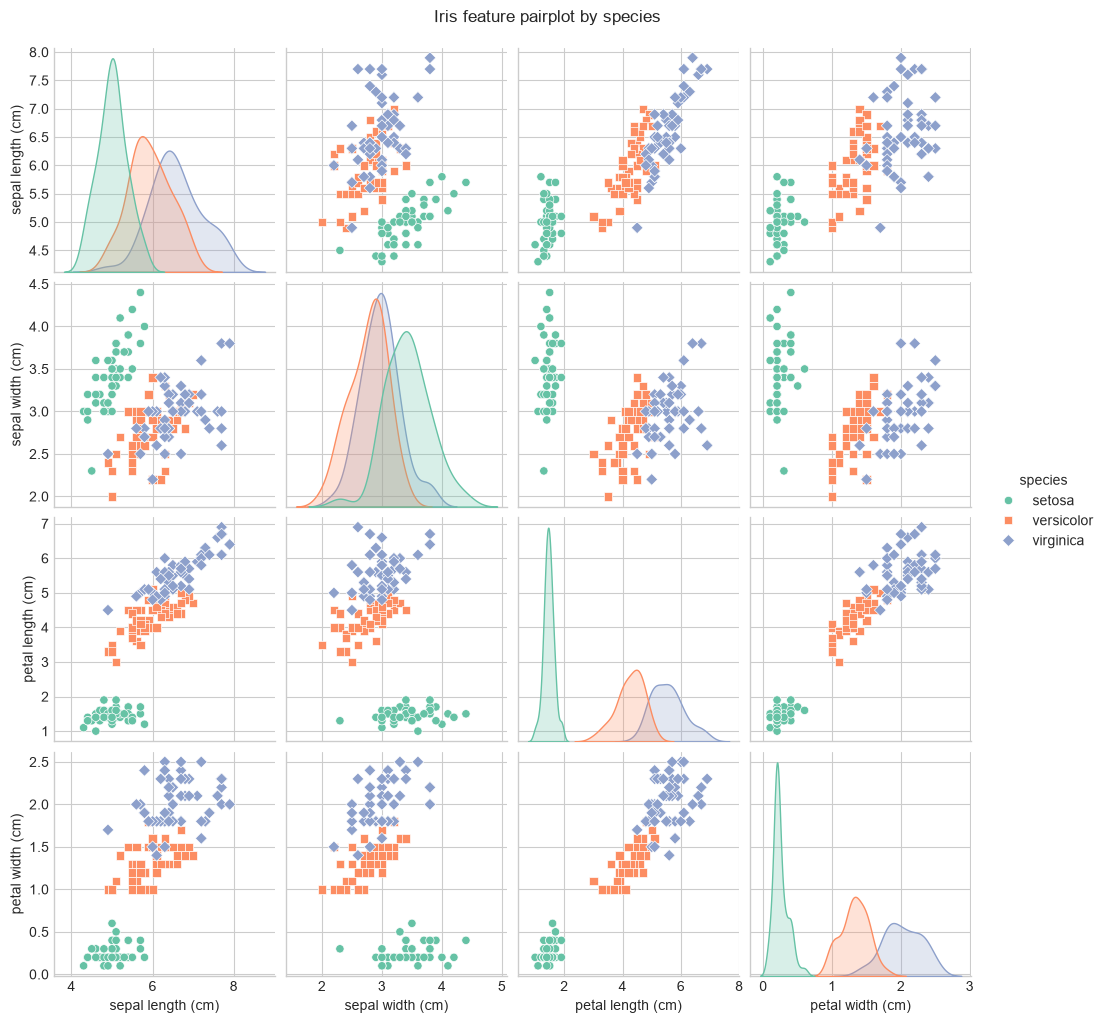

In [4]:
# Pairplot showing feature distributions by species
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'], palette='Set2')
plt.suptitle('Iris feature pairplot by species', y=1.02)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_18668\366945323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y=feature, ax=ax, palette='Set2')
C:\Users\asus\AppData\Local\Temp\ipykernel_18668\366945323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y=feature, ax=ax, palette='Set2')
C:\Users\asus\AppData\Local\Temp\ipykernel_18668\366945323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y=feature, ax=ax, palette='Set2')


C:\Users\asus\AppData\Local\Temp\ipykernel_18668\366945323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y=feature, ax=ax, palette='Set2')


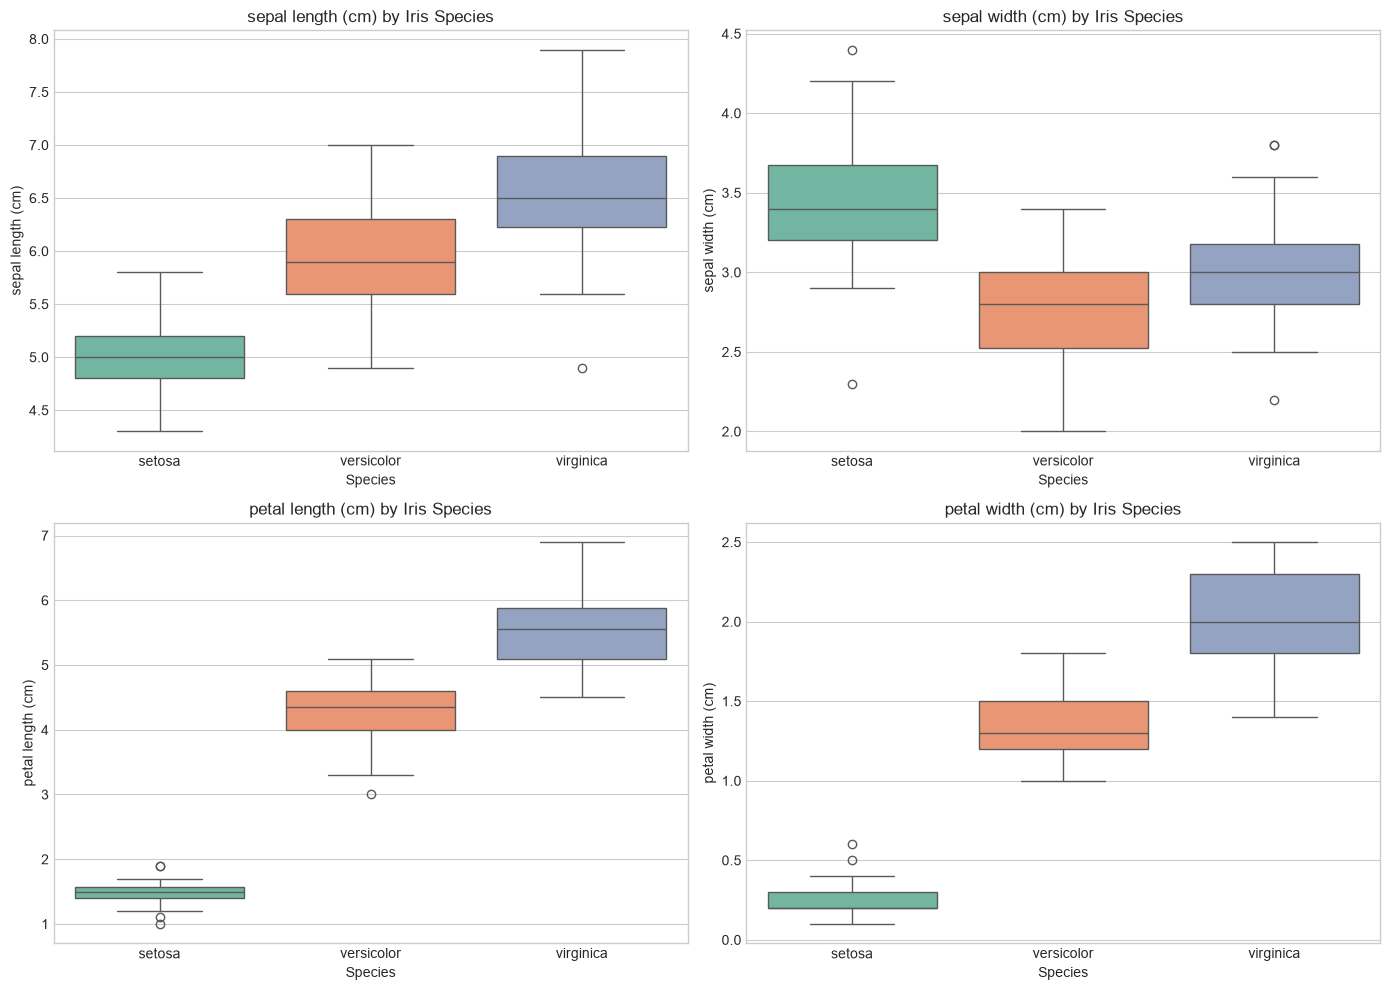

In [5]:
# Boxplot for each feature grouped by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
feature_names = list(feature_names)

for ax, feature in zip(axes.flat, feature_names):
    sns.boxplot(data=iris_df, x='species', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Iris Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## Feature Selection Discussion

The Petal Length and Petal Width features are the strongest discriminators because they separate the three species much more clearly than Sepal Length or Sepal Width. This is visible in the pairplots and boxplots:
- Setosa has short petals and small petal widths.
- Versicolor and Virginica are more separated by petal dimensions, especially petal length.
- Sepal features still carry useful information, but they overlap more across classes.

In [6]:
# Split dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Train samples: 120
Test samples: 30



Logistic Regression
--------------------------------------------------
Accuracy: 0.9667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



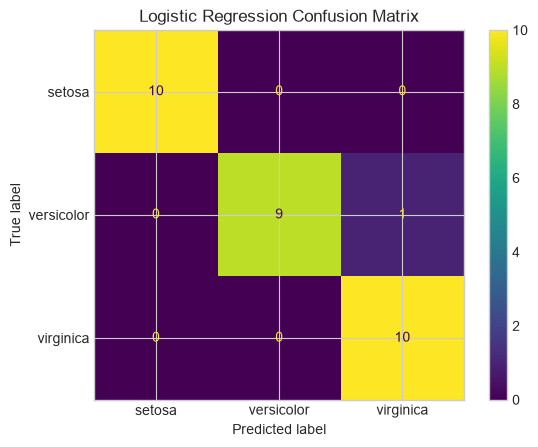


KNN
--------------------------------------------------
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



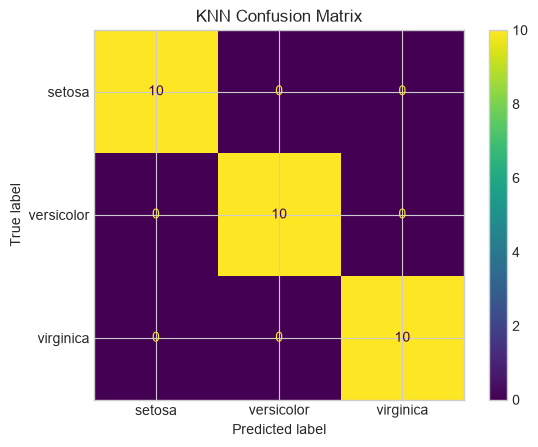


Decision Tree
--------------------------------------------------
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



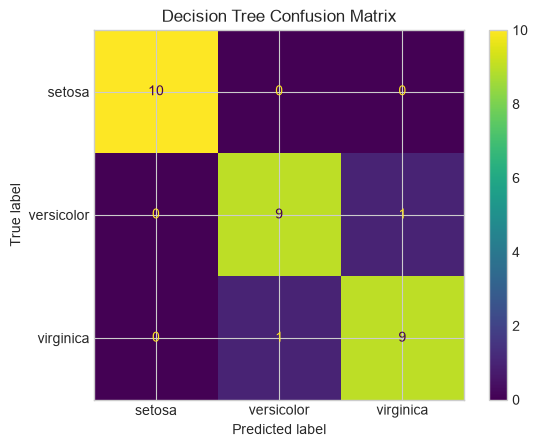


Random Forest
--------------------------------------------------
Accuracy: 0.9000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



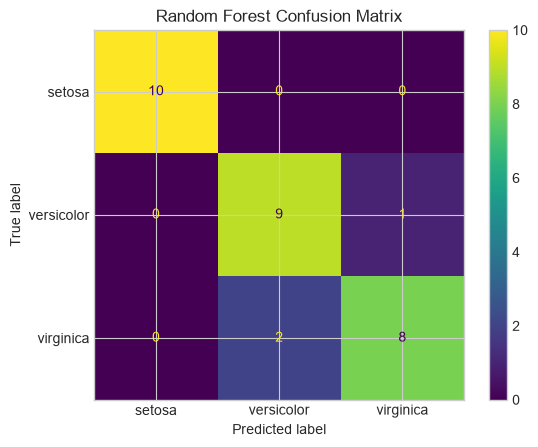

In [7]:
# Train multiple classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=4),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    # Predict on the test set
    y_pred = model.predict(X_test)
    # Compute model metrics
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

    results.append({
        'name': name,
        'model': model,
        'accuracy': acc,
        'confusion_matrix': cm,
        'classification_report': cr,
    })

    print(f'\n{name}')
    print('-' * 50)
    print(f'Accuracy: {acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=target_names))

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names).plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

In [8]:
# Identify the best-performing model after evaluating all four classifiers
best = max(results, key=lambda item: item['accuracy'])
best_name = best['name']
best_accuracy = best['accuracy']

print(f'Best-performing model: {best_name}')
print(f'Accuracy: {best_accuracy:.4f}')
print('Justification: The best-performing model is the one with the highest test accuracy and the most balanced precision/recall scores across all three classes.')

Best-performing model: KNN
Accuracy: 1.0000
Justification: The best-performing model is the one with the highest test accuracy and the most balanced precision/recall scores across all three classes.
